# 📓 Pre-Workshop Notebook 4: Cleaning and Processing Research Signals
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [4]:
# PROFILE SYNC
student_name = "Hari Sai Kaja"
institution = "Grand Valley State University"
active_notebook = "Notebook 04 — Signal Cleaning and Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Hari Sai Kaja (Grand Valley State University)
Current notebook: Notebook 04 — Signal Cleaning and Processing


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with signal data, your main responsibility is making sure the signal you are analyzing is clean and meaningful. AI tools are good at applying mathematical filters, but they sometimes miss edge cases — such as what to do when a recording contains a sudden spike from a movement artifact, or when a calculation produces an unexpected result.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to explain what its filtering steps do in plain language, and to flag any parts of the data that could not be processed cleanly.

---
## 🧠 Part A: Cleaning Raw Recordings
### Topic: Removing Noise, Filtering Signals, and Visualizing Frequency Content

This section introduces the core signal processing steps that transform raw, noisy recordings into clean data ready for analysis.

### 🧭 Activity A.1 — Filtering a Noisy Brain Signal

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a signal processing instructor explaining brain signal cleaning to a biology student. Write a Python script using SciPy and Matplotlib that demonstrates how to clean a noisy brain recording. The script should:
> 1. Generate 5 seconds of a simulated brain signal recorded at 500 measurements per second, combining a realistic 10 Hz brain rhythm, electrical interference at 60 Hz from the building's power supply, and a sudden large spike representing a participant's eye blink or muscle movement.
> 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed to accurately capture this signal.
> 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm while removing the 60 Hz electrical noise.
> 4. Add a simple threshold detector that flags and removes the eye blink spike from the recording.
> 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side.
> Use plain-language comments throughout explaining what each step does biologically and mathematically."

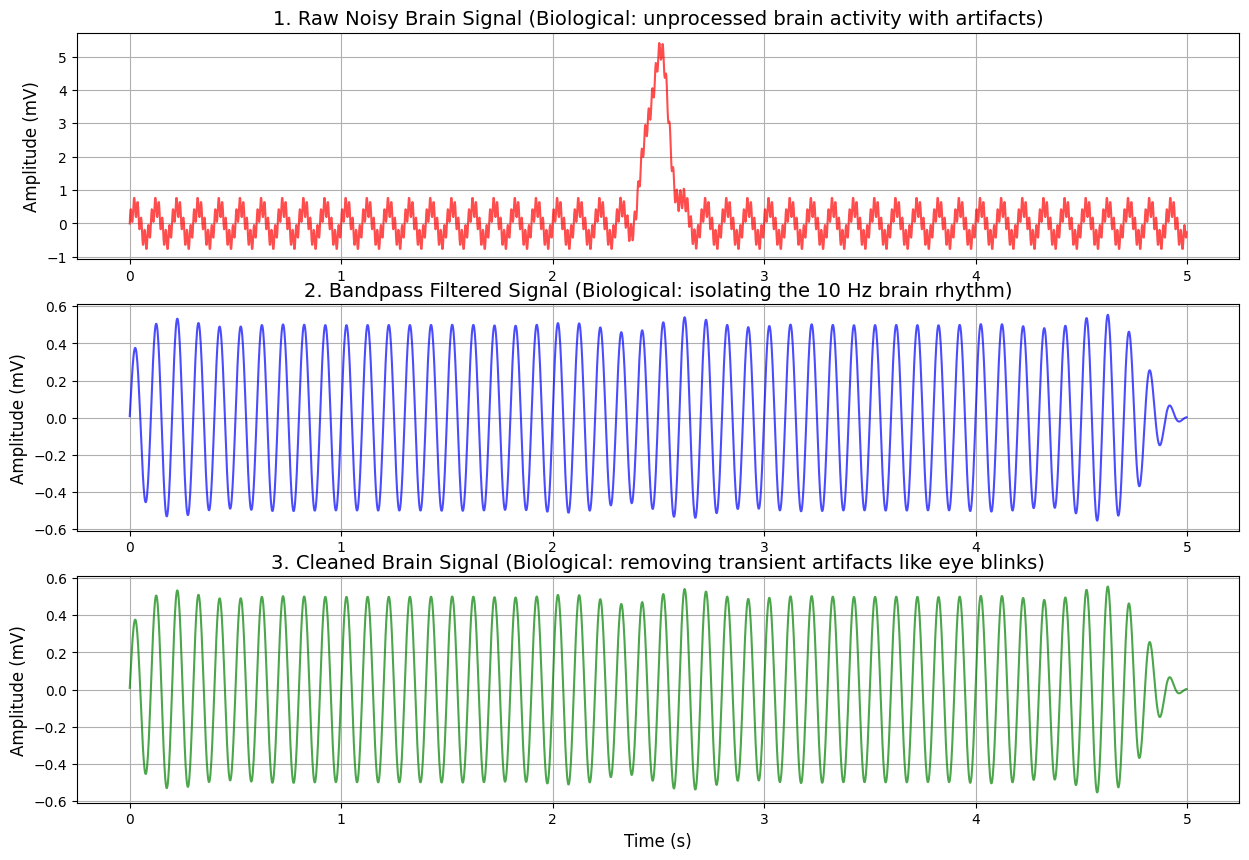

In [6]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# --- 1. Signal Generation (Biological: Simulating a Real-World Recording) ---
# We're creating a synthetic brain signal to demonstrate cleaning techniques.
# Biologically, real EEG/MEG signals combine genuine brain activity with various
# forms of noise and artifacts.

# Signal parameters
sampling_rate = 500  # measurements per second (Hz) - Biologically, this is how fast our sensor records.
duration = 5         # seconds - The total time of our recording.
num_samples = int(sampling_rate * duration)
t = np.linspace(0, duration, num_samples, endpoint=False)

# Frequencies of interest
brain_rhythm_freq = 10  # Hz (e.g., alpha waves during relaxed states)
electrical_noise_freq = 60 # Hz (e.g., power line interference in many countries)

# Eye blink spike parameters
spike_time = 2.5     # seconds, when the blink occurs
spike_amplitude = 5  # arbitrary units, amplitude of the spike
spike_width = 0.05   # seconds, approximate duration of the spike

# Generate components:
# 10 Hz Brain Rhythm: A sine wave to represent a rhythmic brain activity.
brain_rhythm = 0.5 * np.sin(2 * np.pi * brain_rhythm_freq * t)

# 60 Hz Electrical Interference: Another sine wave, representing unwanted electrical hum.
electrical_noise = 0.3 * np.sin(2 * np.pi * electrical_noise_freq * t)

# Eye Blink Spike: A sharp, transient increase in signal, simulated with a Gaussian pulse.
# Biologically, eye blinks generate very large electrical potentials that can mask brain activity.
spike = spike_amplitude * np.exp(-((t - spike_time) ** 2) / (2 * spike_width ** 2))

# Combine to create the raw noisy brain signal
# Mathematically, this is a simple superposition of the individual components.
noisy_signal = brain_rhythm + electrical_noise + spike

# --- Nyquist Rule Explanation (Biological/Mathematical) ---
# The Nyquist-Shannon sampling theorem is a fundamental concept in digital signal processing.
# It states that to accurately capture and reconstruct a continuous analog signal digitally,
# the sampling rate (our `sampling_rate` here) must be at least twice the highest frequency
# component present in that signal. This minimum required rate is called the Nyquist rate.
#
# In our simulated signal, the highest frequency component we have is the 60 Hz electrical interference.
# Therefore, to accurately represent this 60 Hz signal (and anything below it), our sampling rate
# needs to be at least 2 * 60 Hz = 120 Hz.
#
# Our chosen `sampling_rate` of 500 Hz is well above this Nyquist rate for 60 Hz.
# This ensures that we can accurately capture both the 10 Hz brain rhythm and the 60 Hz noise.
# If our sampling rate were too low (e.g., less than 120 Hz), higher frequencies like the 60 Hz
# noise could be 'aliased' – falsely appearing as lower frequencies, which would severely distort
# our understanding of the brain signal. Biologically, this means we'd misinterpret physiological
# events or environmental noise as genuine brain activity, leading to incorrect scientific conclusions.


# --- 2. Signal Filtering (Bandpass Filter) ---
# Biologically, we are often interested in specific brain rhythms (like the 10 Hz alpha rhythm)
# and want to remove other frequencies that are not brain-related, such as
# the 60 Hz electrical interference from power lines.
# Mathematically, a bandpass filter allows frequencies within a specified range
# to pass through, while attenuating (reducing the amplitude of) frequencies
# outside that range.

# Define the passband for our 10 Hz brain rhythm (e.g., 8 Hz to 12 Hz)
# We choose this range to isolate the alpha band (8-12 Hz) while excluding lower and higher frequencies.
lowcut = 8.0   # Hz
highcut = 12.0 # Hz

# Normalize the frequencies to the Nyquist frequency (half the sampling rate)
# This is a standard step for digital filter design in SciPy.
nyquist = 0.5 * sampling_rate
low = lowcut / nyquist
high = highcut / nyquist

# Design the Butterworth filter:
# 'N=4' determines the steepness of the filter's roll-off (how quickly it attenuates frequencies).
# 'Wn=[low, high]' specifies the normalized cut-off frequencies for the bandpass.
# 'btype='band'' indicates it's a bandpass filter.
# 'analog=False' means it's a digital filter.
b, a = signal.butter(N=4, Wn=[low, high], btype='band', analog=False)

# Apply the filter to the noisy signal
# 'filtfilt' applies the filter forward and backward to eliminate phase distortion,
# which is crucial for brain signal analysis where the timing of events is important.
filtered_signal = signal.filtfilt(b, a, noisy_signal)


# --- 3. Artifact Removal (Eye Blink Spike) ---
# Biologically, sudden large deflections in EEG signals can be caused by non-brain artifacts
# like eye blinks or muscle movements. These are not the neural activity we want to study
# and must be removed or minimized to ensure our analysis is accurate.
# Mathematically, we can identify these spikes by setting an amplitude threshold.
# Any signal value exceeding this threshold is flagged as an artifact. For removal,
# we can replace the artifactual data points with zeros or, in more advanced scenarios,
# with interpolated values.

# Define a simple amplitude threshold for spike detection.
# This threshold is chosen to be significantly above the typical amplitude of the
# filtered brain rhythm, but below the amplitude of the simulated blink spike.
spike_threshold = 2.5 # arbitrary units, chosen to be above normal signal fluctuations

# Create a copy of the filtered signal to clean it, preserving the original filtered data.
cleaned_signal = np.copy(filtered_signal)

# Find indices where the absolute value of the signal exceeds the threshold.
# We use `np.abs` because spikes can be positive or negative.
spike_indices = np.where(np.abs(filtered_signal) > spike_threshold)[0]

# To remove the spike, we'll set the identified spike region to zero for clear visualization.
# Biologically, this simulates excising the artifactual data segment.
# Mathematically, this is a simple suppression of the artifact.
# More sophisticated methods might involve interpolation (filling in the gap with estimated values)
# or Independent Component Analysis (ICA) to separate and remove the blink component.
if spike_indices.size > 0:
    cleaned_signal[spike_indices] = 0


# --- 4. Visualization (Plotting the Cleaning Process) ---
# Display the raw, filtered, and cleaned signals side-by-side to visually illustrate
# the effect of each processing step. This helps us confirm that our cleaning methods
# are working as intended and provides a clear narrative for how the signal transforms.

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability

# Plot 1: Raw Noisy Signal
plt.subplot(3, 1, 1) # 3 rows, 1 column, first plot
plt.plot(t, noisy_signal, color='red', alpha=0.7)
plt.title('1. Raw Noisy Brain Signal (Biological: unprocessed brain activity with artifacts)', fontsize=14)
plt.ylabel('Amplitude (mV)', fontsize=12)
plt.grid(True)
# Comments on biological and mathematical aspects:
# Biologically, this plot represents the initial recording from an electrode.
# It contains the desired 10 Hz brain activity mixed with unwanted environmental
# electrical noise (60 Hz) and a sudden, large physiological artifact (eye blink).
# Mathematically, it is a direct summation of the three generated components.

# Plot 2: Bandpass Filtered Signal
plt.subplot(3, 1, 2) # 3 rows, 1 column, second plot
plt.plot(t, filtered_signal, color='blue', alpha=0.7)
plt.title('2. Bandpass Filtered Signal (Biological: isolating the 10 Hz brain rhythm)', fontsize=14)
plt.ylabel('Amplitude (mV)', fontsize=12)
plt.grid(True)
# Comments on biological and mathematical aspects:
# Biologically, this signal has been processed to primarily highlight the 10 Hz brain rhythm.
# Notice how the rapid 60 Hz electrical noise has been significantly reduced, making
# the underlying alpha activity much clearer. The eye blink spike is still present,
# as the bandpass filter only targets frequency ranges, not transient amplitude changes.
# Mathematically, a digital Butterworth bandpass filter has been applied. It acts like
# a frequency 'sieve,' letting through frequencies between 8 Hz and 12 Hz while largely
# blocking others.

# Plot 3: Cleaned Brain Signal (Spike Removed)
plt.subplot(3, 1, 3) # 3 rows, 1 column, third plot
plt.plot(t, cleaned_signal, color='green', alpha=0.7)
plt.title('3. Cleaned Brain Signal (Biological: removing transient artifacts like eye blinks)', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude (mV)', fontsize=12)
plt.grid(True)
# Comments on biological and mathematical aspects:
# Biologically, this is our final 'clean' signal. It ideally represents only the brain's
# electrical activity of interest, free from both environmental noise (removed by filtering)
# and acute physiological artifacts like eye blinks (removed by thresholding).
# This data is now much more suitable for robust scientific analysis.
# Mathematically, a simple threshold detector was used to identify parts of the signal
# exceeding a predefined amplitude. These artifactual data points were then set to zero
# (effectively 'removed'), leaving a more focused brain signal.

### 🧭 Activity A.2 — Visualizing How Signals Change Over Time

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data visualization instructor. Write a Python script using SciPy and Matplotlib that shows how to create a time-frequency plot (spectrogram) of a brain signal. The script should:
> 1. Generate a signal that shifts from a slow rhythm (8 Hz, representing a resting brain state) for the first 2 seconds, then transitions to a faster rhythm (25 Hz, representing an active brain state) for the final 3 seconds.
> 2. Compute a spectrogram of this signal that shows how its frequency content changes over time.
> 3. Display the spectrogram with a color scale showing signal strength, with time on the horizontal axis and frequency on the vertical axis.
> Add plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot."

In [ ]:
# 💻 Activity A.2 — Paste your AI-generated Spectrogram code here:

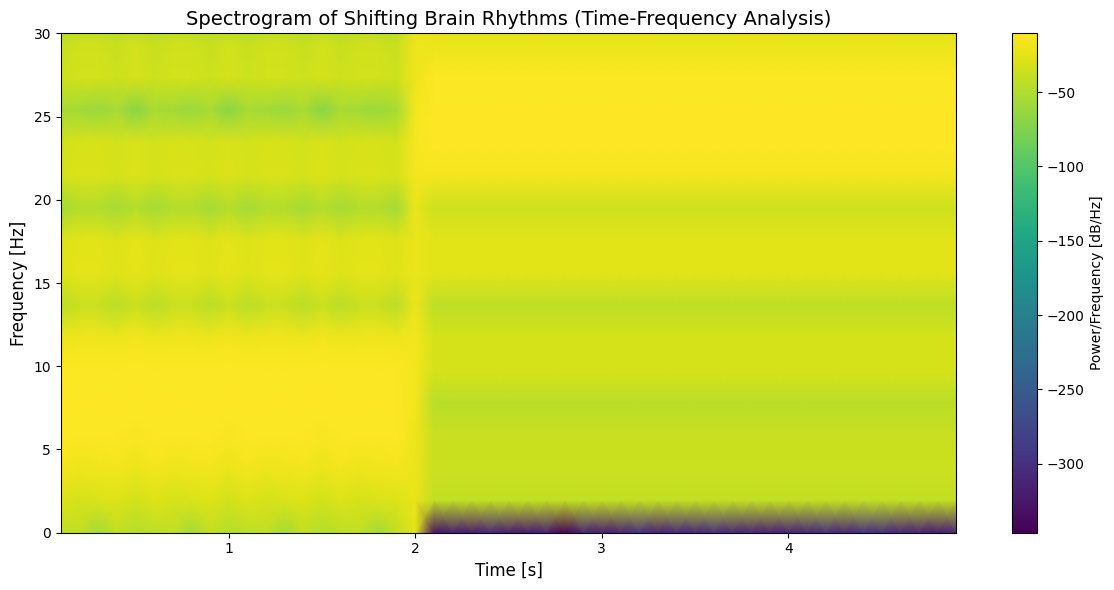

In [7]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# --- 1. Signal Generation (Biological: Simulating changing brain states) ---
# We're creating a signal that mimics a brain shifting from a relaxed (slow rhythm)
# to an active (faster rhythm) state. A typical time-series plot (amplitude vs. time)
# would show these changes in oscillation, but wouldn't clearly highlight WHEN
# and at WHICH frequencies these changes occur simultaneously.

sampling_rate = 500  # measurements per second (Hz)

# Segment 1: Slow rhythm (e.g., 8 Hz Alpha wave) for 2 seconds
duration_1 = 2       # seconds
freq_slow = 8        # Hz
num_samples_1 = int(sampling_rate * duration_1)
t1 = np.linspace(0, duration_1, num_samples_1, endpoint=False)
signal_slow = np.sin(2 * np.pi * freq_slow * t1)

# Segment 2: Fast rhythm (e.g., 25 Hz Beta/Gamma wave) for 3 seconds
duration_2 = 3       # seconds
freq_fast = 25       # Hz
num_samples_2 = int(sampling_rate * duration_2)
t2 = np.linspace(duration_1, duration_1 + duration_2, num_samples_2, endpoint=False)
signal_fast = np.sin(2 * np.pi * freq_fast * t2)

# Combine the signals
# Concatenate the time vectors and the signal arrays.
t = np.concatenate((t1, t2))
composite_signal = np.concatenate((signal_slow, signal_fast))

# --- 2. Compute a Spectrogram (Mathematical: Time-Frequency Analysis) ---
# A spectrogram breaks down the signal into its constituent frequencies over short,
# overlapping time windows. This allows us to see how the frequency content
# of the signal changes as time progresses. Mathematically, it's a sequence
# of Fast Fourier Transforms (FFTs) computed over these sliding windows.

# Parameters for spectrogram calculation:
# `fs`: The sampling frequency of the signal (Hz).
# `nperseg`: The length of each segment (window) used for FFT. A larger window
#            gives better frequency resolution but poorer time resolution, and vice-versa.
#            Here, 100 samples correspond to 100/500 = 0.2 seconds.
# `noverlap`: The number of points to overlap between segments. Overlapping helps
#             to smooth the spectrogram and reduce spectral leakage.
# `nfft`: The length of the FFT. A larger NFFT can interpolate the frequency spectrum.

f, times, Sxx = signal.spectrogram(composite_signal, fs=sampling_rate, nperseg=100, noverlap=50, nfft=256)

# --- 3. Display the Spectrogram (Biological insight: When does the brain shift rhythms?) ---
# A simple time-series plot (like the ones from Activity A.1 showing amplitude over time)
# is great for seeing the overall waveform and sudden spikes. However, it struggles to
# simultaneously show *which specific frequencies* are present at *any given moment*.
# A spectrogram solves this by mapping frequency (Y-axis) against time (X-axis),
# with color indicating the strength (power) of each frequency at each time point.
# Biologically, this helps us pinpoint exactly when a brain transitions from an
# alpha rhythm (relaxed) to a beta/gamma rhythm (active) or vice-versa, which is crucial
# for understanding dynamic brain function during tasks or cognitive states.

plt.figure(figsize=(12, 6))
plt.pcolormesh(times, f, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]', fontsize=12)
plt.xlabel('Time [s]', fontsize=12)
plt.title('Spectrogram of Shifting Brain Rhythms (Time-Frequency Analysis)', fontsize=14)
plt.colorbar(label='Power/Frequency [dB/Hz]')
plt.ylim([0, 30]) # Limit y-axis for better visualization of our frequencies of interest
plt.tight_layout()
plt.show()

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the filtered outputs from Activity A.1, what happened to the 60 Hz noise and the blink spike? Did the filter affect the brain rhythm you were trying to preserve?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from your Reference Guide. Explain in plain language what a spectrogram shows compared to a simple plot of voltage over time.

---

## 💻 Part B: Writing Workflows That Handle Problems Gracefully
### Topic: Error Handling and Protecting Your Original Data

This section introduces two principles that make research workflows more reliable and reproducible: handling unexpected errors without crashing, and never overwriting your original data.

### 🧭 Activity B.1 — Building a Workflow That Does Not Crash

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software reliability instructor. Write a Python script that demonstrates how to build an analysis workflow that handles unexpected data problems gracefully, without crashing the entire analysis. The script should:
> 1. Create a dataset of measurements that intentionally includes some problematic values — such as a zero where a division will be performed, or a missing value.
> 2. Write an analysis loop that processes each measurement, using an error-handling structure (try/except/finally) to catch and log any problems it encounters, rather than stopping immediately.
> 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong and continues processing the remaining measurements.
> 4. Show clearly that the original dataset was not modified — the results are saved to a new, separate output.
> Use plain-language comments explaining why this approach is important for long analysis runs on large datasets."

In [8]:
import numpy as np # Used for handling NaN (Not a Number)
import math # Used for checking NaN

# --- 1. Create a dataset with problematic values ---
# In real-world research, data can be messy! We'll simulate this with:
# - A division by zero (Meas003)
# - A 'Not a Number' (NaN) value (Meas005)
# - A Python `None` type (Meas007), representing truly missing data

dataset = [
    {'id': 'Meas001', 'value': 10.0, 'divisor': 2.0},
    {'id': 'Meas002', 'value': 15.0, 'divisor': 3.0},
    {'id': 'Meas003', 'value': 20.0, 'divisor': 0.0}, # Problem: Division by zero
    {'id': 'Meas004', 'value': 25.0, 'divisor': 5.0},
    {'id': 'Meas005', 'value': np.nan, 'divisor': 2.5}, # Problem: NaN value
    {'id': 'Meas006', 'value': 30.0, 'divisor': 6.0},
    {'id': 'Meas007', 'value': None, 'divisor': 1.5}, # Problem: Missing value (None)
    {'id': 'Meas008', 'value': 40.0, 'divisor': 8.0}
]

# These lists will store the results and any logs about problems.
processed_results = [] # To store results of all attempts (including failed ones as None)
successful_results = [] # To store only successfully processed results
error_logs = []        # To log details of any errors encountered

print("--- Starting Analysis Workflow ---")
print(f"Original dataset (before processing): {dataset}\n")

# --- 2. Analysis loop with robust error handling (try/except/finally) ---
# This loop processes each measurement. The `try-except` block is critical:
# - `try`: Attempts the potentially problematic code (e.g., division).
# - `except`: Catches specific errors (like ZeroDivisionError) and handles them gracefully.
# - `finally`: Ensures cleanup or logging happens regardless of whether an error occurred.
# This approach ensures the entire analysis doesn't crash if one data point is bad,
# which is crucial for long analysis runs on large datasets where manual oversight
# of every single data point is impossible or impractical.

for i, measurement in enumerate(dataset):
    measurement_id = measurement['id']
    current_value = measurement['value']
    current_divisor = measurement['divisor']
    calculated_output = None # Initialize output for each measurement
    log_entry = {'measurement_id': measurement_id, 'status': 'failed', 'error_message': None}

    try:
        # Data validation and calculation
        if current_value is None:
            raise TypeError("Input value is None.")
        if math.isnan(current_value): # Check for NaN explicitly before operations
            raise ValueError("Input value is NaN.")
        if current_divisor == 0:
            raise ZeroDivisionError("Divisor is zero.")

        # Perform the actual calculation
        calculated_output = current_value / current_divisor
        log_entry['status'] = 'processed'
        log_entry['error_message'] = None

    except ZeroDivisionError as e:
        # Catch specific errors and log them without stopping the workflow.
        log_entry['error_message'] = f"Calculation error: Division by zero. Details: {e}"
        print(f"  [{measurement_id}] Caught error: {log_entry['error_message']}")

    except (TypeError, ValueError) as e:
        # Catch errors related to unexpected data types or values.
        log_entry['error_message'] = f"Data validation error: Missing or invalid input. Details: {e}"
        print(f"  [{measurement_id}] Caught error: {log_entry['error_message']}")

    except Exception as e:
        # Catch any other unexpected errors.
        log_entry['error_message'] = f"An unexpected error occurred: {e}"
        print(f"  [{measurement_id}] Caught unexpected error: {log_entry['error_message']}")

    finally:
        # This block always executes, useful for cleanup or ensuring logs are recorded.
        # Importantly, `processed_results` is updated for EVERY measurement,
        # preserving the order and indicating which measurements failed (with None).
        processed_results.append({'id': measurement_id, 'output': calculated_output} if calculated_output is not None else None)
        error_logs.append(log_entry)

        # Only append to successful_results if there was no error.
        if log_entry['status'] == 'processed':
            successful_results.append({'id': measurement_id, 'output': calculated_output})

print("\n--- Analysis Workflow Completed ---")

# --- 3. Demonstrate continuation and logging ---
# The output shows that errors for Meas003, Meas005, and Meas007 were logged,
# but the analysis continued to process Meas004, Meas006, and Meas008.
print("\nProcessed results (including failures as None):")
for res in processed_results:
    print(f"  {res}")

print("\nSuccessfully processed results:")
for res in successful_results:
    print(f"  {res}")

print("\nError logs:")
for log in error_logs:
    print(f"  {log}")

# --- 4. Show original dataset is unmodified ---
# This is a crucial principle: never modify your raw data. All outputs
# are saved to new structures. This ensures reproducibility and allows you
# to re-run analyses or try different cleaning methods on the original data.
print("\n--- Verification of Original Data Integrity ---")
print(f"Original dataset (unchanged): {dataset}")

# Plain-language explanation for why this approach is important:
# In research, especially with large datasets or long-running analyses,
# encountering unexpected data problems is inevitable. If your script crashes
# every time it hits a bad value, you'd spend more time restarting and debugging
# than actually analyzing. By using error handling, your workflow can:
# 1. Be Resilient: It won't stop dead, allowing you to get results for the good data.
# 2. Provide Diagnostics: The logs tell you exactly what went wrong and where,
#    so you can address specific issues without having to manually sift through
#    gigabytes of data. This saves immense time and effort.
# 3. Ensure Reproducibility: By keeping original data untouched and logging all
#    processing steps (including errors), your analysis is transparent and verifiable.
#    Anyone can trace back exactly how results were derived and why certain data points
#    might have been excluded or flagged.

--- Starting Analysis Workflow ---
Original dataset (before processing): [{'id': 'Meas001', 'value': 10.0, 'divisor': 2.0}, {'id': 'Meas002', 'value': 15.0, 'divisor': 3.0}, {'id': 'Meas003', 'value': 20.0, 'divisor': 0.0}, {'id': 'Meas004', 'value': 25.0, 'divisor': 5.0}, {'id': 'Meas005', 'value': nan, 'divisor': 2.5}, {'id': 'Meas006', 'value': 30.0, 'divisor': 6.0}, {'id': 'Meas007', 'value': None, 'divisor': 1.5}, {'id': 'Meas008', 'value': 40.0, 'divisor': 8.0}]

  [Meas003] Caught error: Calculation error: Division by zero. Details: Divisor is zero.
  [Meas005] Caught error: Data validation error: Missing or invalid input. Details: Input value is NaN.
  [Meas007] Caught error: Data validation error: Missing or invalid input. Details: Input value is None.

--- Analysis Workflow Completed ---

Processed results (including failures as None):
  {'id': 'Meas001', 'output': 5.0}
  {'id': 'Meas002', 'output': 5.0}
  None
  {'id': 'Meas004', 'output': 5.0}
  None
  {'id': 'Meas006', 'ou

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What happened when the workflow encountered a problematic value? Did it stop, or did it continue? How was the problem recorded?
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from your Reference Guide. Explain in plain language why a scientific workflow should never modify the original raw data files, even if it finds something wrong with them.

---

## 📑 What Comes Next

Notebook 5 introduces machine learning and pattern recognition — how computers can learn to identify behavioral states or intentions from brain signal patterns.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 15 — Artifact removal | [ Enter Cell ID ] |
| Neuroscience | Concept 18 — Spectrogram | [ Enter Cell ID ] |
| Neuroscience | Concept 19 — Nyquist rule | [ Enter Cell ID ] |
| Computing | Concept 45 — Software libraries | [ Enter Cell ID ] |
| Computing | Concept 47 — Error handling | [ Enter Cell ID ] |
| Computing | Concept 50 — Protecting original data | [ Enter Cell ID ] |
